# 🔬 Centralized Experiment Runner & Scientific Evaluation Dashboard

Welcome to the centralized dashboard for your deep learning rotation robustness research on **ModelNet10**. This notebook acts as the unified cockpit to orchestrate, evaluate, and compare all your baselines, from scratch-trained models to transfer-learned ResNet18 variants.

### 📍 Experimental Workflow
1. **Train**: Run custom CNNs (`ModelS`) or Transfer Learning (`ModelT`) experiments.
2. **Evaluate**: Extract overall metrics, generate confusion matrices, and measure viewpoint sensitivity over all 12 angles.
3. **Compare**: Create publication-grade comparative rotation curves and generate your statistical results CSV.

> **💡 GPU Memory Tip:** To prevent CUDA memory fragmentation and ensure reproducibility, we spawn separate processes for training runs. This releases GPU resources cleanly between experiments.

In [1]:
import os
import sys
import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Ensure project root is in path for custom module loading
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print(f"📂 Working Directory set to Project Root: {os.getcwd()}")
print(f"🖥️ CUDA Available: {os.popen('nvidia-smi').read() != ''}")

📂 Working Directory set to Project Root: /home/nofa/School/Masters/SSC/DL_Project
🖥️ CUDA Available: True


## 🛠️ Step 1: Load and View Available Configurations

All experiment specs are declared in `configs/experiments.yaml`. Let's parse and display what we can run.

In [2]:
with open("configs/experiments.yaml", "r") as f:
    experiments = yaml.safe_load(f)

print("🚀 Available Experiments in Config File:")
print(json.dumps(experiments, indent=4))

🚀 Available Experiments in Config File:
{
    "S-1": {
        "model": "model_s",
        "optimizer": "adamw",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "loss": "ce",
        "augmentation": false
    },
    "S-2": {
        "model": "model_s",
        "optimizer": "sgd",
        "lr": 0.01,
        "momentum": 0.9,
        "nesterov": true,
        "weight_decay": 0.0001,
        "loss": "ce",
        "augmentation": false
    },
    "S-3": {
        "model": "model_s",
        "optimizer": "adamw",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "loss": "ce",
        "augmentation": true
    },
    "S-4": {
        "model": "model_s",
        "optimizer": "adamw",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "loss": "label_smoothing",
        "augmentation": false
    },
    "T-FE-1": {
        "model": "model_t",
        "optimizer": "adamw",
        "lr": 0.001,
        "weight_decay": 0.0001,
        "loss": "ce",
        "augmenta

## ⚙️ Step 2: Centralized Process Launcher

Use this section to train any of the experiments dynamically.

In [3]:
def run_experiment(exp_name):
    """
    Spawns a training run for a given experiment config.
    """
    print(f"\n🔥 Launching Experiment: {exp_name}...")
    cmd = f"PYTHONPATH=. uv run python scripts/run_experiment.py --exp {exp_name}"
    # Run and stream output
    os.system(cmd)
    print(f"✅ Finished training/verifying {exp_name}.")

In [4]:
run_experiment("S-1")


🔥 Launching Experiment: S-1...

🚀 Running Experiment: S-1
{'model': 'model_s', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': False}

📊 Model Computational & Structural Profiling Summary:
   Total Parameters:      2,492,170
   Trainable Parameters:  2,492,170
   Frozen Parameters:     0
   Estimated Complexity:  742,099,402 MACs (FLOPs)



Train 0: 100%|██████████| 281/281 [00:35<00:00,  7.81it/s]


Epoch 0: train_acc=0.7320, val_acc=0.5754, lr=0.001000
🏆 Saved new best checkpoint at epoch 0 with validation accuracy: 0.5754


Train 1: 100%|██████████| 281/281 [00:35<00:00,  7.82it/s]


Epoch 1: train_acc=0.8437, val_acc=0.8899, lr=0.001000
🏆 Saved new best checkpoint at epoch 1 with validation accuracy: 0.8899


...

Epoch 27: train_acc=0.9625, val_acc=0.9298, lr=0.001000
ℹ️ No improvement. Early stopping patience: 4/10


Train 28: 100%|██████████| 281/281 [00:34<00:00,  8.04it/s]


Epoch 28: train_acc=0.9601, val_acc=0.9436, lr=0.001000
ℹ️ No improvement. Early stopping patience: 5/10


Train 29: 100%|██████████| 281/281 [00:35<00:00,  7.93it/s]


Epoch 29: train_acc=0.9631, val_acc=0.9330, lr=0.001000
ℹ️ No improvement. Early stopping patience: 6/10
🔄 Restored best model weights from epoch 23 (val_acc: 0.9449)
✅ Finished S-1 | Best Val Acc: 0.9449
✅ Finished training/verifying S-1.


In [5]:
run_experiment("S-2")


🔥 Launching Experiment: S-2...

🚀 Running Experiment: S-2
{'model': 'model_s', 'optimizer': 'sgd', 'lr': 0.01, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': False}

📊 Model Computational & Structural Profiling Summary:
   Total Parameters:      2,492,170
   Trainable Parameters:  2,492,170
   Frozen Parameters:     0
   Estimated Complexity:  742,099,402 MACs (FLOPs)



Train 0: 100%|██████████| 281/281 [00:33<00:00,  8.37it/s]


Epoch 0: train_acc=0.7478, val_acc=0.8251, lr=0.010000
🏆 Saved new best checkpoint at epoch 0 with validation accuracy: 0.8251


Train 1: 100%|██████████| 281/281 [00:32<00:00,  8.73it/s]


Epoch 1: train_acc=0.8424, val_acc=0.8743, lr=0.010000
🏆 Saved new best checkpoint at epoch 1 with validation accuracy: 0.8743


...

Epoch 27: train_acc=0.9552, val_acc=0.9286, lr=0.010000
ℹ️ No improvement. Early stopping patience: 3/10


Train 28: 100%|██████████| 281/281 [00:34<00:00,  8.22it/s]


Epoch 28: train_acc=0.9555, val_acc=0.9416, lr=0.010000
🏆 Saved new best checkpoint at epoch 28 with validation accuracy: 0.9416


Train 29: 100%|██████████| 281/281 [00:33<00:00,  8.45it/s]


Epoch 29: train_acc=0.9604, val_acc=0.9373, lr=0.010000
ℹ️ No improvement. Early stopping patience: 1/10
🔄 Restored best model weights from epoch 28 (val_acc: 0.9416)
✅ Finished S-2 | Best Val Acc: 0.9416
✅ Finished training/verifying S-2.


In [6]:
run_experiment("S-3")


🔥 Launching Experiment: S-3...

🚀 Running Experiment: S-3
{'model': 'model_s', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': True}

📊 Model Computational & Structural Profiling Summary:
   Total Parameters:      2,492,170
   Trainable Parameters:  2,492,170
   Frozen Parameters:     0
   Estimated Complexity:  742,099,402 MACs (FLOPs)



Train 0: 100%|██████████| 281/281 [00:32<00:00,  8.54it/s]


Epoch 0: train_acc=0.6767, val_acc=0.8033, lr=0.001000
🏆 Saved new best checkpoint at epoch 0 with validation accuracy: 0.8033


Train 1: 100%|██████████| 281/281 [00:34<00:00,  8.26it/s]


Epoch 1: train_acc=0.7881, val_acc=0.8478, lr=0.001000
🏆 Saved new best checkpoint at epoch 1 with validation accuracy: 0.8478


...

Epoch 27: train_acc=0.9202, val_acc=0.9207, lr=0.001000
ℹ️ No improvement. Early stopping patience: 3/10


Train 28: 100%|██████████| 281/281 [00:33<00:00,  8.42it/s]


Epoch 28: train_acc=0.9181, val_acc=0.9300, lr=0.001000
🏆 Saved new best checkpoint at epoch 28 with validation accuracy: 0.9300


Train 29: 100%|██████████| 281/281 [00:34<00:00,  8.19it/s]


Epoch 29: train_acc=0.9223, val_acc=0.9198, lr=0.001000
ℹ️ No improvement. Early stopping patience: 1/10
🔄 Restored best model weights from epoch 28 (val_acc: 0.9300)
✅ Finished S-3 | Best Val Acc: 0.9300
✅ Finished training/verifying S-3.


In [7]:
run_experiment("S-4")


🔥 Launching Experiment: S-4...

🚀 Running Experiment: S-4
{'model': 'model_s', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'label_smoothing', 'augmentation': False}

📊 Model Computational & Structural Profiling Summary:
   Total Parameters:      2,492,170
   Trainable Parameters:  2,492,170
   Frozen Parameters:     0
   Estimated Complexity:  742,099,402 MACs (FLOPs)



Train 0: 100%|██████████| 281/281 [00:33<00:00,  8.40it/s]


Epoch 0: train_acc=0.7312, val_acc=0.8620, lr=0.001000
🏆 Saved new best checkpoint at epoch 0 with validation accuracy: 0.8620


Train 1: 100%|██████████| 281/281 [00:33<00:00,  8.35it/s]


Epoch 1: train_acc=0.8529, val_acc=0.8903, lr=0.001000
🏆 Saved new best checkpoint at epoch 1 with validation accuracy: 0.8903


...

Epoch 27: train_acc=0.9826, val_acc=0.9438, lr=0.001000
ℹ️ No improvement. Early stopping patience: 4/10


Train 28: 100%|██████████| 281/281 [00:32<00:00,  8.75it/s]


Epoch 28: train_acc=0.9847, val_acc=0.9327, lr=0.001000
ℹ️ No improvement. Early stopping patience: 5/10


Train 29: 100%|██████████| 281/281 [00:32<00:00,  8.75it/s]


Epoch 29: train_acc=0.9866, val_acc=0.9397, lr=0.001000
ℹ️ No improvement. Early stopping patience: 6/10
🔄 Restored best model weights from epoch 23 (val_acc: 0.9513)
✅ Finished S-4 | Best Val Acc: 0.9513
✅ Finished training/verifying S-4.


In [8]:
run_experiment("T-FE-1")


🔥 Launching Experiment: T-FE-1...

🚀 Running Experiment: T-FE-1
{'model': 'model_t', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': False, 'freeze': True, 'pretrained': True, 'normalize': True}

📊 Model Computational & Structural Profiling Summary:
   Total Parameters:      11,444,298
   Trainable Parameters:  267,786
   Frozen Parameters:     11,176,512
   Estimated Complexity:  1,813,838,730 MACs (FLOPs)



Train 0: 100%|██████████| 281/281 [00:13<00:00, 21.08it/s]


Epoch 0: train_acc=0.7674, val_acc=0.8537, lr=0.001000
🏆 Saved new best checkpoint at epoch 0 with validation accuracy: 0.8537


Train 1: 100%|██████████| 281/281 [00:12<00:00, 22.18it/s]


Epoch 1: train_acc=0.8528, val_acc=0.8747, lr=0.001000
🏆 Saved new best checkpoint at epoch 1 with validation accuracy: 0.8747


...

Epoch 27: train_acc=0.9370, val_acc=0.9101, lr=0.001000
ℹ️ No improvement. Early stopping patience: 4/10


Train 28: 100%|██████████| 281/281 [00:13<00:00, 21.40it/s]


Epoch 28: train_acc=0.9418, val_acc=0.9177, lr=0.001000
🏆 Saved new best checkpoint at epoch 28 with validation accuracy: 0.9177


Train 29: 100%|██████████| 281/281 [00:13<00:00, 21.42it/s]


Epoch 29: train_acc=0.9437, val_acc=0.9134, lr=0.001000
ℹ️ No improvement. Early stopping patience: 1/10
🔄 Restored best model weights from epoch 28 (val_acc: 0.9177)
✅ Finished T-FE-1 | Best Val Acc: 0.9177
✅ Finished training/verifying T-FE-1.


In [9]:
run_experiment("T-FE-2")


🔥 Launching Experiment: T-FE-2...

🚀 Running Experiment: T-FE-2
{'model': 'model_t', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': True, 'freeze': True, 'pretrained': True, 'normalize': True}

📊 Model Computational & Structural Profiling Summary:
   Total Parameters:      11,444,298
   Trainable Parameters:  267,786
   Frozen Parameters:     11,176,512
   Estimated Complexity:  1,813,838,730 MACs (FLOPs)



Train 0: 100%|██████████| 281/281 [00:17<00:00, 16.32it/s]


Epoch 0: train_acc=0.7013, val_acc=0.8004, lr=0.001000
🏆 Saved new best checkpoint at epoch 0 with validation accuracy: 0.8004


Train 1: 100%|██████████| 281/281 [00:16<00:00, 16.55it/s]


Epoch 1: train_acc=0.7893, val_acc=0.8298, lr=0.001000
🏆 Saved new best checkpoint at epoch 1 with validation accuracy: 0.8298


...

Epoch 27: train_acc=0.8621, val_acc=0.8776, lr=0.001000
ℹ️ No improvement. Early stopping patience: 1/10


Train 28: 100%|██████████| 281/281 [00:16<00:00, 16.97it/s]


Epoch 28: train_acc=0.8577, val_acc=0.8759, lr=0.001000
ℹ️ No improvement. Early stopping patience: 2/10


Train 29: 100%|██████████| 281/281 [00:16<00:00, 16.89it/s]


Epoch 29: train_acc=0.8613, val_acc=0.8776, lr=0.001000
ℹ️ No improvement. Early stopping patience: 3/10
🔄 Restored best model weights from epoch 26 (val_acc: 0.8801)
✅ Finished T-FE-2 | Best Val Acc: 0.8801
✅ Finished training/verifying T-FE-2.


In [10]:
run_experiment("T-FT-1")


🔥 Launching Experiment: T-FT-1...

🚀 Running Experiment: T-FT-1
{'model': 'model_t', 'optimizer': 'adamw', 'lr': 0.0001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': False, 'freeze': False, 'pretrained': True, 'normalize': True}

📊 Model Computational & Structural Profiling Summary:
   Total Parameters:      11,444,298
   Trainable Parameters:  11,444,298
   Frozen Parameters:     0
   Estimated Complexity:  1,813,838,730 MACs (FLOPs)



Train 0: 100%|██████████| 281/281 [00:32<00:00,  8.62it/s]


Epoch 0: train_acc=0.8776, val_acc=0.9316, lr=0.000100
🏆 Saved new best checkpoint at epoch 0 with validation accuracy: 0.9316


Train 1: 100%|██████████| 281/281 [00:31<00:00,  8.79it/s]


Epoch 1: train_acc=0.9512, val_acc=0.9418, lr=0.000100
🏆 Saved new best checkpoint at epoch 1 with validation accuracy: 0.9418


...

Epoch 13: train_acc=0.9882, val_acc=0.9586, lr=0.000100
ℹ️ No improvement. Early stopping patience: 8/10


Train 14: 100%|██████████| 281/281 [00:32<00:00,  8.77it/s]


Epoch 14: train_acc=0.9935, val_acc=0.9535, lr=0.000100
ℹ️ No improvement. Early stopping patience: 9/10


Train 15: 100%|██████████| 281/281 [00:32<00:00,  8.77it/s]


Epoch 15: train_acc=0.9927, val_acc=0.9527, lr=0.000100
ℹ️ No improvement. Early stopping patience: 10/10
🛑 Early stopping triggered at epoch 15. Restoring best weights...
🔄 Restored best model weights from epoch 5 (val_acc: 0.9592)
✅ Finished T-FT-1 | Best Val Acc: 0.9592
✅ Finished training/verifying T-FT-1.


In [11]:
run_experiment("T-FT-2")


🔥 Launching Experiment: T-FT-2...

🚀 Running Experiment: T-FT-2
{'model': 'model_t', 'optimizer': 'adamw', 'lr': 0.0001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': True, 'freeze': False, 'pretrained': True, 'normalize': True}

📊 Model Computational & Structural Profiling Summary:
   Total Parameters:      11,444,298
   Trainable Parameters:  11,444,298
   Frozen Parameters:     0
   Estimated Complexity:  1,813,838,730 MACs (FLOPs)



Train 0: 100%|██████████| 281/281 [00:32<00:00,  8.59it/s]


Epoch 0: train_acc=0.8477, val_acc=0.9271, lr=0.000100
🏆 Saved new best checkpoint at epoch 0 with validation accuracy: 0.9271


Train 1: 100%|██████████| 281/281 [00:32<00:00,  8.76it/s]


Epoch 1: train_acc=0.9253, val_acc=0.9341, lr=0.000100
🏆 Saved new best checkpoint at epoch 1 with validation accuracy: 0.9341


...

Epoch 25: train_acc=0.9821, val_acc=0.9574, lr=0.000100
ℹ️ No improvement. Early stopping patience: 8/10


Train 26: 100%|██████████| 281/281 [00:32<00:00,  8.76it/s]


Epoch 26: train_acc=0.9818, val_acc=0.9524, lr=0.000100
ℹ️ No improvement. Early stopping patience: 9/10


Train 27: 100%|██████████| 281/281 [00:32<00:00,  8.75it/s]


Epoch 27: train_acc=0.9824, val_acc=0.9547, lr=0.000100
ℹ️ No improvement. Early stopping patience: 10/10
🛑 Early stopping triggered at epoch 27. Restoring best weights...
🔄 Restored best model weights from epoch 17 (val_acc: 0.9601)
✅ Finished T-FT-2 | Best Val Acc: 0.9601
✅ Finished training/verifying T-FT-2.


## 🔎 Step 3: Run Scientific Multi-View Evaluations

Once training completes, evaluate your checkpoints against the out-of-distribution rotation testing domain ($0^\circ \dots 330^\circ$ in $30^\circ$ increments).

In [12]:
def evaluate_experiment(exp_name, split="val"):
    """
    Runs multi-view scientific evaluation and generates metrics + curve plots.
    """
    ckpt_path = f"outputs/{exp_name}/checkpoints/best.pt"
    if not os.path.exists(ckpt_path):
        print(f"⚠️ Error: Checkpoint not found for {exp_name} at {ckpt_path}")
        return
        
    print(f"\n🕵️ Evaluating Checkpoint: {ckpt_path} on split: {split}...")
    cmd = f"PYTHONPATH=. uv run python scripts/evaluate_checkpoint.py --ckpt {ckpt_path} --split {split}"
    os.system(cmd)
    print(f"✅ Evaluation complete for {exp_name}.")

In [13]:
# Scientific evaluation of all 8 competed experiments across 12 viewpoints
for exp in ['S-1','S-2', 'S-3', 'S-4', 'T-FE-1', 'T-FE-2', 'T-FT-1', 'T-FT-2', 'Eq-1', 'Eq-2']:
    evaluate_experiment(exp, split='val')



🕵️ Evaluating Checkpoint: outputs/S-1/checkpoints/best.pt on split: val...
🖥️ Using device: cuda
📖 Loaded experiment config from: outputs/S-1/config.yaml
🏗️ Building model...
📈 Loaded Rich Checkpoint Metadata | Best Val Accuracy: 0.9449 | Saved at Epoch: 23
✅ Model loaded and weights restored successfully!
📋 Loaded 'val' split with 11172 images (all 12 views included).
🕵️ Running forward pass...

📊 --- Overall Split [VAL] Metrics ---
Loss:      0.6575
Accuracy:  0.8441 (84.41%)
Precision: 0.8068
Recall:    0.8191
Macro F1:  0.8023

🖼️ Saved Confusion Matrix plot to: outputs/S-1/figures/confusion_matrix.png

🔄 Running Rotation Sensitivity Analysis...
   Angle   0° (View  0): Accuracy = 0.9484 (883/931)
   Angle  30° (View  1): Accuracy = 0.9463 (881/931)
   Angle  60° (View  2): Accuracy = 0.9366 (872/931)
   Angle  90° (View  3): Accuracy = 0.9452 (880/931)
   Angle 120° (View  4): Accuracy = 0.9484 (883/931)
   Angle 150° (View  5): Accuracy = 0.9441 (879/931)
   Angle 180° (View  6)

/home/nofa/School/Masters/SSC/DL_Project/.venv/lib/python3.12/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


📈 Loaded Rich Checkpoint Metadata | Best Val Accuracy: 0.8645 | Saved at Epoch: 25
✅ Model loaded and weights restored successfully!
📋 Loaded 'val' split with 11172 images (all 12 views included).
🕵️ Running forward pass...

📊 --- Overall Split [VAL] Metrics ---
Loss:      0.5993
Accuracy:  0.7954 (79.54%)
Precision: 0.7437
Recall:    0.7578
Macro F1:  0.7455

🖼️ Saved Confusion Matrix plot to: outputs/Eq-1/figures/confusion_matrix.png

🔄 Running Rotation Sensitivity Analysis...
   Angle   0° (View  0): Accuracy = 0.8238 (767/931)
   Angle  30° (View  1): Accuracy = 0.8915 (830/931)
   Angle  60° (View  2): Accuracy = 0.8915 (830/931)
   Angle  90° (View  3): Accuracy = 0.8238 (767/931)
   Angle 120° (View  4): Accuracy = 0.8797 (819/931)
   Angle 150° (View  5): Accuracy = 0.8765 (816/931)
   Angle 180° (View  6): Accuracy = 0.6165 (574/931)
   Angle 210° (View  7): Accuracy = 0.7487 (697/931)
   Angle 240° (View  8): Accuracy = 0.7734 (720/931)
   Angle 270° (View  9): Accuracy = 0.6

/home/nofa/School/Masters/SSC/DL_Project/.venv/lib/python3.12/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


📈 Loaded Rich Checkpoint Metadata | Best Val Accuracy: 0.8264 | Saved at Epoch: 24
✅ Model loaded and weights restored successfully!
📋 Loaded 'val' split with 11172 images (all 12 views included).
🕵️ Running forward pass...

📊 --- Overall Split [VAL] Metrics ---
Loss:      0.6135
Accuracy:  0.7907 (79.07%)
Precision: 0.7311
Recall:    0.7145
Macro F1:  0.7126

🖼️ Saved Confusion Matrix plot to: outputs/Eq-2/figures/confusion_matrix.png

🔄 Running Rotation Sensitivity Analysis...
   Angle   0° (View  0): Accuracy = 0.8013 (746/931)
   Angle  30° (View  1): Accuracy = 0.8335 (776/931)
   Angle  60° (View  2): Accuracy = 0.8346 (777/931)
   Angle  90° (View  3): Accuracy = 0.8153 (759/931)
   Angle 120° (View  4): Accuracy = 0.8432 (785/931)
   Angle 150° (View  5): Accuracy = 0.8303 (773/931)
   Angle 180° (View  6): Accuracy = 0.6284 (585/931)
   Angle 210° (View  7): Accuracy = 0.8099 (754/931)
   Angle 240° (View  8): Accuracy = 0.7916 (737/931)
   Angle 270° (View  9): Accuracy = 0.7

## 📈 Step 4: Multi-Model Comparison Dashboard

Generate side-by-side plots and statistical summary tables across all completed experiments. Change `--exps` to list the models you wish to compare.

In [14]:
# Define the experiments you want to include in your comparative analysis
active_experiments = 'S-1,S-2,S-3,S-4,T-FE-1,T-FE-2,T-FT-1,T-FT-2,Eq-1,Eq-2'

print(f"📊 Aggregating curves and metrics for: {active_experiments}...")
cmd = f"PYTHONPATH=. uv run python scripts/generate_comparison.py --exps {active_experiments}"
os.system(cmd)

# Load and display statistical summary table
summary_df = pd.read_csv("outputs/comparisons/results_summary.csv")
summary_df['deg_180_drop'] = summary_df['deg_180_drop'].apply(lambda x: f"{x:.1%}")

print("\n🏆 STATISTICAL ANALYSIS TABLE:")
display(summary_df)


📊 Aggregating curves and metrics for: S-1,S-2,S-3,S-4,T-FE-1,T-FE-2,T-FT-1,T-FT-2,Eq-1,Eq-2...
📊 Generating comparison for experiments: ['S-1', 'S-2', 'S-3', 'S-4', 'T-FE-1', 'T-FE-2', 'T-FT-1', 'T-FT-2', 'Eq-1', 'Eq-2']
   Loaded results for S-1
   Loaded results for S-2
   Loaded results for S-3
   Loaded results for S-4
   Loaded results for T-FE-1
   Loaded results for T-FE-2
   Loaded results for T-FT-1
   Loaded results for T-FT-2
   Loaded results for Eq-1
   Loaded results for Eq-2
🖼️ Saved comparative rotation plot to: outputs/comparisons/rotation_curve_comparison.png
💾 Saved statistical results summary CSV to: outputs/comparisons/results_summary.csv

📈 ==================== COMPARATIVE RESULTS ====================
Model      | Overall Acc | Macro F1   | Rotation AUC | 180° Drop (D)
--------------------------------------------------------------------
S-1        | 0.8441      | 0.8023     | 0.8397       | 23.2%
S-2        | 0.7922      | 0.7459     | 0.7901       | 21.5%
S-3    

,model,acc,f1,auc,deg_180_drop
0,S-1,0.8441,0.8023,0.8397,23.2%
1,S-2,0.7922,0.7459,0.7901,21.5%
2,S-3,0.8891,0.8324,0.8880,7.2%
3,S-4,0.8410,0.7989,0.8363,18.7%
4,T-FE-1,0.8685,0.8271,0.8672,21.0%
5,T-FE-2,0.8498,0.7917,0.8492,14.0%
6,T-FT-1,0.9055,0.8680,0.9050,10.0%
7,T-FT-2,0.9247,0.8879,0.9246,8.3%
8,Eq-1,0.7954,0.7455,0.7941,25.2%
9,Eq-2,0.7907,0.7126,0.7905,21.6%


### 🖼️ Rotation Sensitivity Curve Comparison

Below is the newly rendered rotation sensitivity comparison curve. This directly contrasts your baselines to evaluate robustness.

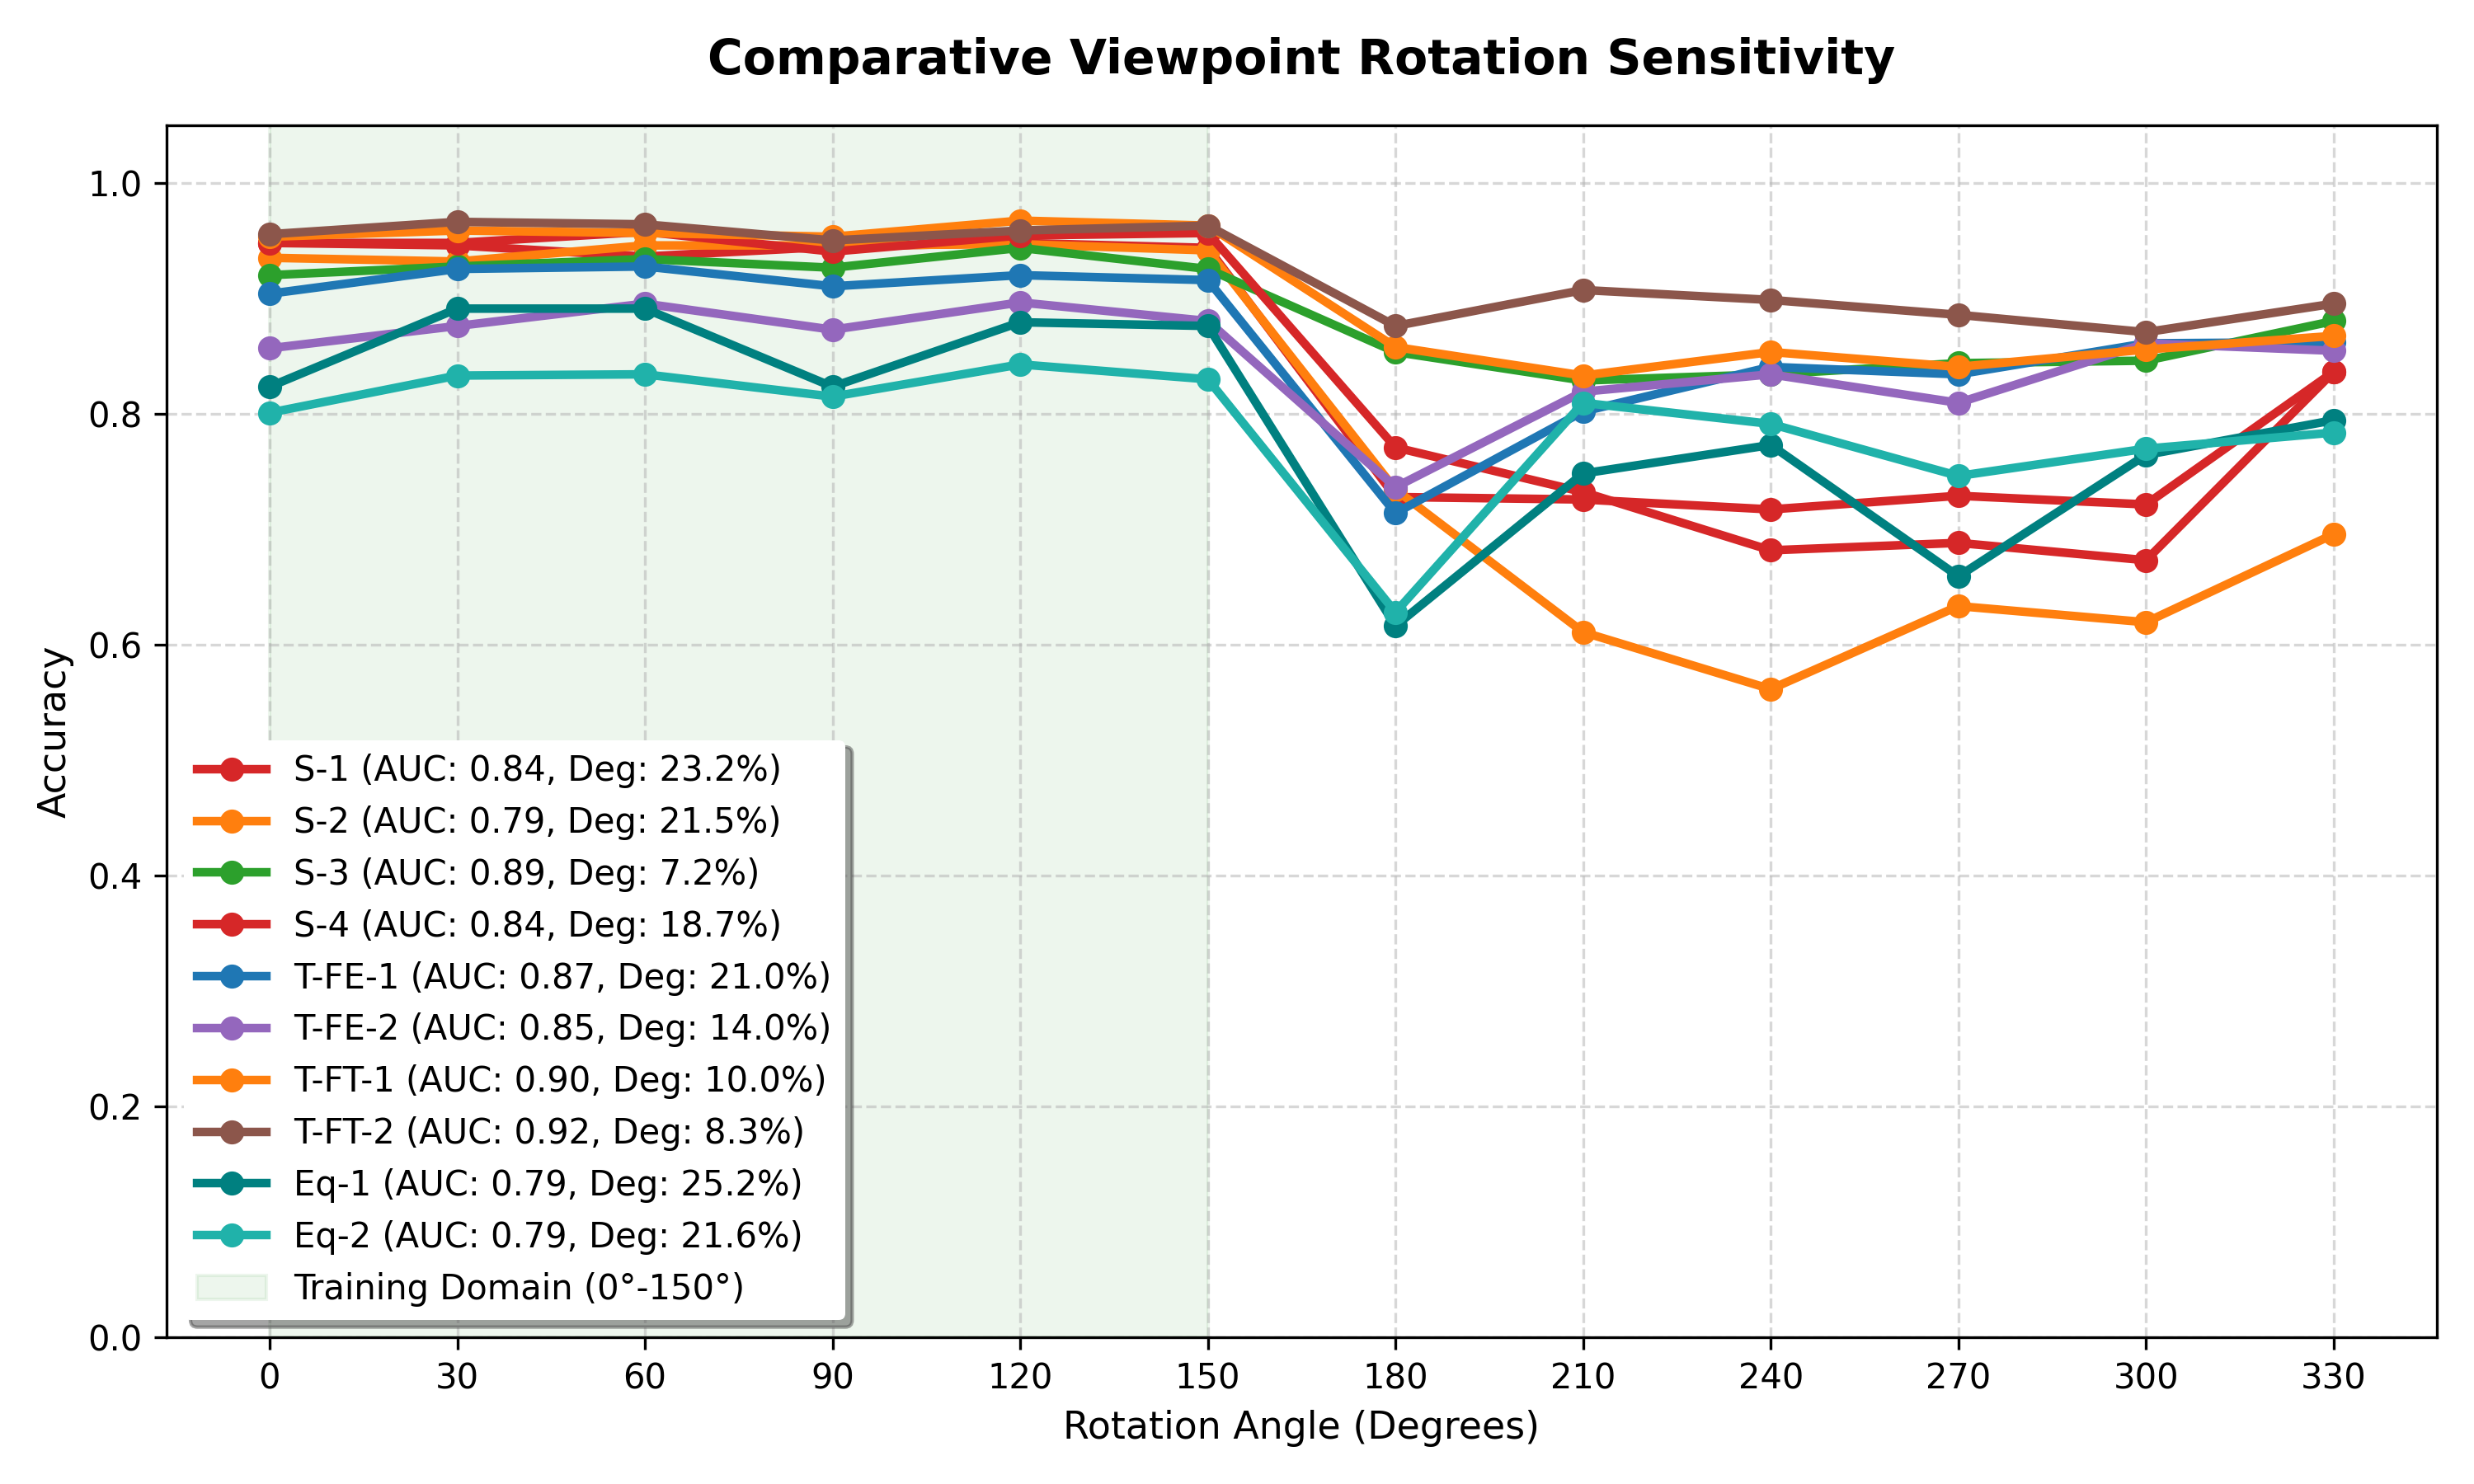

In [15]:
comparison_plot = "outputs/comparisons/rotation_curve_comparison.png"
if os.path.exists(comparison_plot):
    display(Image(filename=comparison_plot, width=800))
else:
    print("⚠️ Plot not found. Make sure to run the comparison code cell first.")

### 🌀 Individual Confusion Matrices

Load and view the individual category-wise confusion matrices for any experiment below.


🖼️ Confusion Matrix for Eq-1:


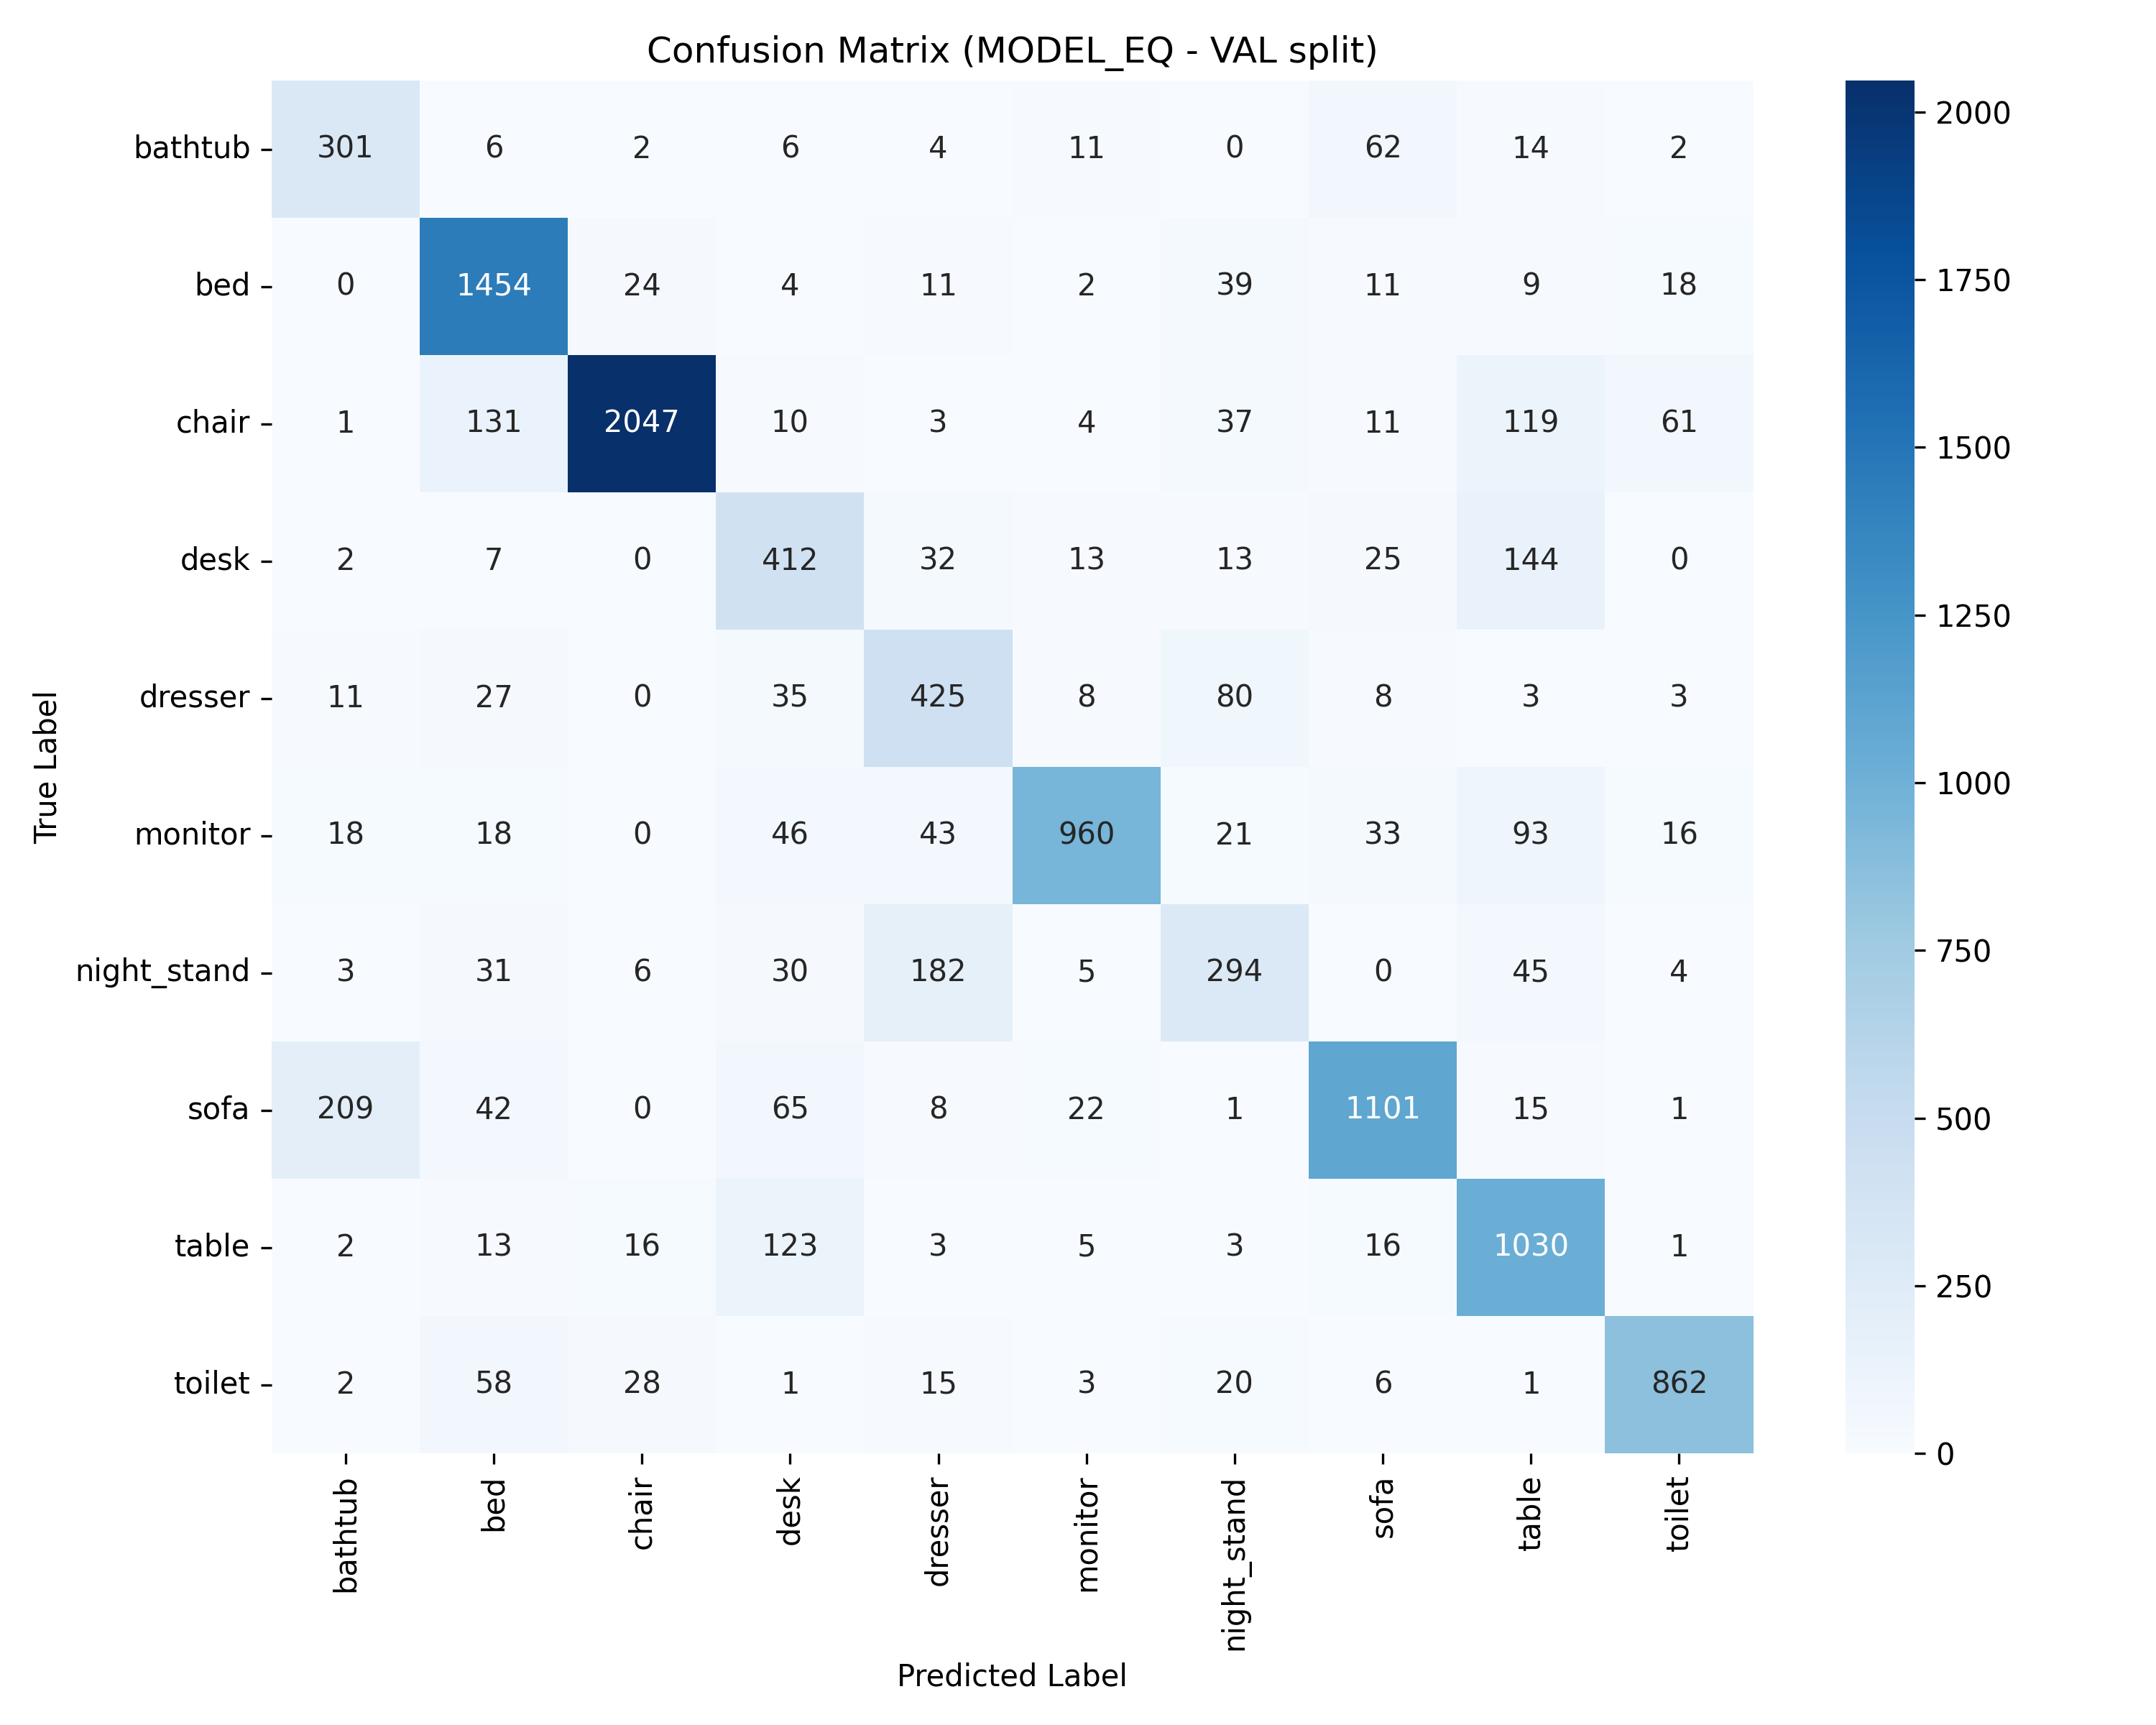

In [16]:
def show_confusion_matrix(exp_name):
    path = f"outputs/{exp_name}/figures/confusion_matrix.png"
    if os.path.exists(path):
        print(f"\n🖼️ Confusion Matrix for {exp_name}:")
        display(Image(filename=path, width=600))
    else:
        print(f"⚠️ Confusion Matrix plot not found at {path}")

show_confusion_matrix("Eq-1")
